In [32]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# from mastercard_challenge import dist_visialsation, dist_categorical_visualisation

In [4]:
PROCESSED_DATA = Path("../data/processed/")
FIGURES_PATH = Path("../reports/figures/")

In [5]:
df = pd.read_parquet(PROCESSED_DATA/ "merchants.parquet")

In [33]:
df.head()

,merchant_id,category,country,trust_score,number_of_alerts_last_6_months,avg_transaction_amount,account_age_months,has_fraud_history
0,M0001,travel,Austria,1.000000,3,97.23,84,0
1,M0002,clothing,Poland,0.689695,2,142.71,93,1
2,M0003,electronics,Czech Republic,0.834610,5,67.83,65,0
3,M0004,electronics,Belgium,0.607229,1,16.77,9,1
4,M0005,grocery,Ireland,0.641901,2,38.56,100,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   merchant_id                     1000 non-null   object 
 1   category                        1000 non-null   object 
 2   country                         1000 non-null   object 
 3   trust_score                     1000 non-null   float64
 4   number_of_alerts_last_6_months  1000 non-null   int64  
 5   avg_transaction_amount          1000 non-null   float64
 6   account_age_months              1000 non-null   int64  
 7   has_fraud_history               1000 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 62.6+ KB


In [11]:
df.describe()

,trust_score,number_of_alerts_last_6_months,avg_transaction_amount,account_age_months,has_fraud_history
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,0.682568,3.06100,81.883090,61.526000,0.52000
std,0.194092,1.72286,79.187529,33.453617,0.49985
min,0.000000,0.00000,0.120000,6.000000,0.00000
25%,0.545615,2.00000,24.772500,32.000000,0.00000
50%,0.697414,3.00000,58.205000,61.000000,1.00000
75%,0.825599,4.00000,117.192500,92.000000,1.00000
max,1.000000,9.00000,709.040000,119.000000,1.00000


In [12]:
import numpy as np
def dist_visualisation(
        data: np.ndarray | pd.Series | list,
        title: str = "",
        show: bool = True
) -> tuple[plt.Figure, dict[str, plt.Axes]] | None:
    """
    Visualize the distribution of data using boxplot, violinplot, and histogram.

    Args:
        data: Input numerical data to visualize.
        title: Title of the entire figure.
        show: If True, displays the plot. If False, returns the figure and axes.

    Returns:
        Tuple of matplotlib figure and axes dictionary if show=False, otherwise None.
    """
    fig = plt.figure(constrained_layout=True)
    plt.style.use('seaborn-v0_8')

    ax_dict = fig.subplot_mosaic([
        ['boxplot', 'violin'],
        ['histogram', 'violin'],
        ['histogram', 'violin'],
    ])

    mean_props = dict(color="darkorange", linestyle="dashed")

    ax_dict['boxplot'].boxplot(
        data,
        showmeans=True,
        meanline=True,
        meanprops=mean_props,
        vert=False
    )

    violin = ax_dict['violin'].violinplot(
        data,
        showmeans=True,
        showmedians=True
    )
    violin["cbars"].set_linestyle('dotted')

    ax_dict['histogram'].hist(data, bins='sqrt', color='orange')

    ax_dict['violin'].set_xlabel('KDE')
    ax_dict['histogram'].set_ylabel('Count Frequency')

    fig.suptitle(title)

    if not show:
        return fig, ax_dict

    plt.show()
    return None

### Numeric values

In [18]:
numerical_cols=['trust_score', 'number_of_alerts_last_6_months','avg_transaction_amount','account_age_months']

In [21]:
df[numerical_cols].skew() # jesli minus to lewoskońsny, a dodatnie to prawoskośny

trust_score                      -0.336082
number_of_alerts_last_6_months    0.462118
avg_transaction_amount            1.896584
account_age_months                0.035148
dtype: float64

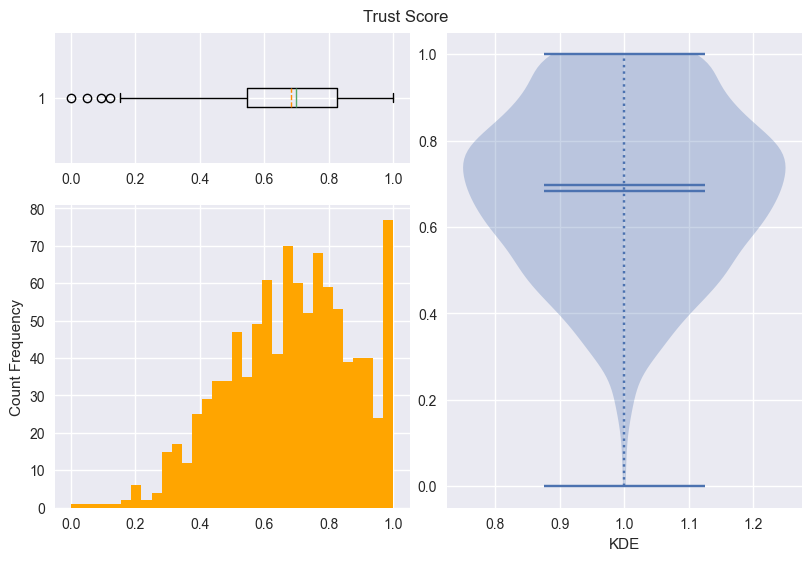

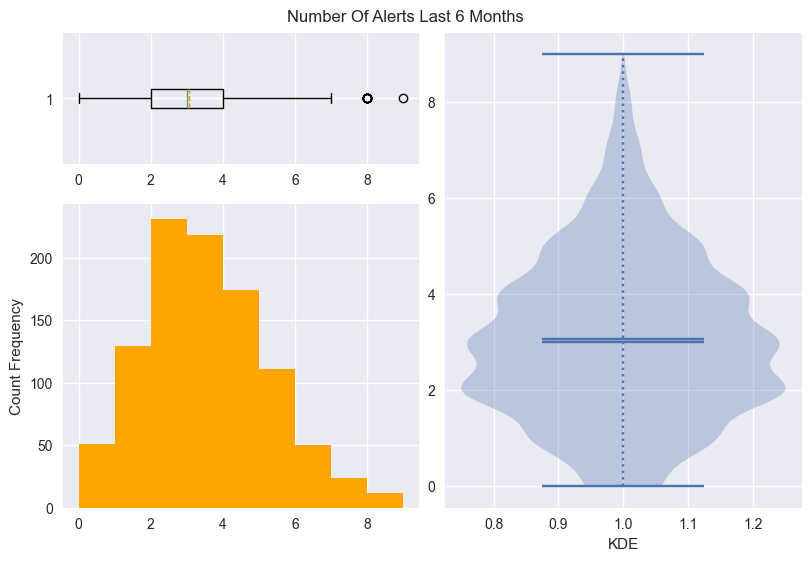

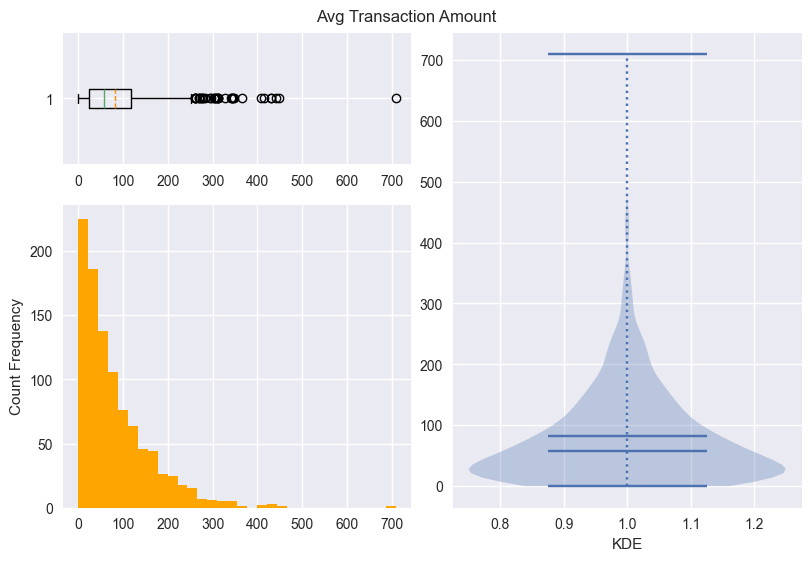

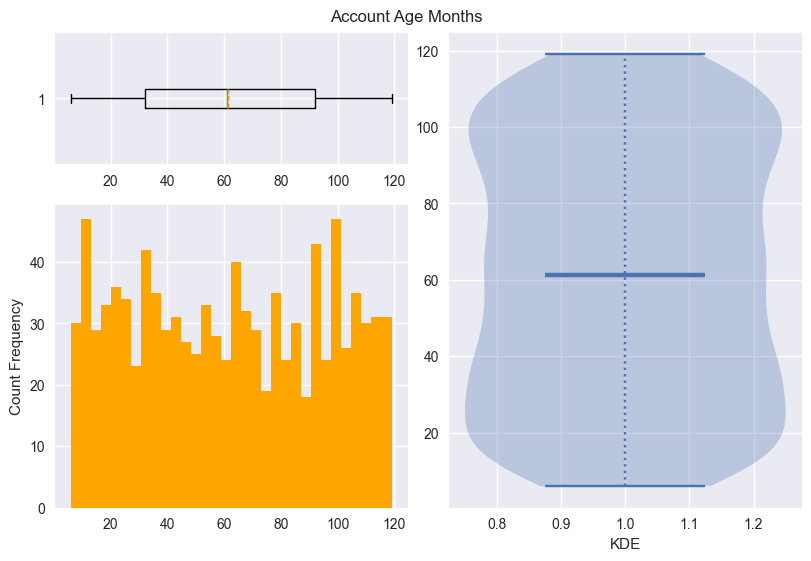

In [19]:
for col in numerical_cols:
    dist_visualisation(df[col], col.title().replace("_", " "))

In [28]:
corr= df[numerical_cols].corr()

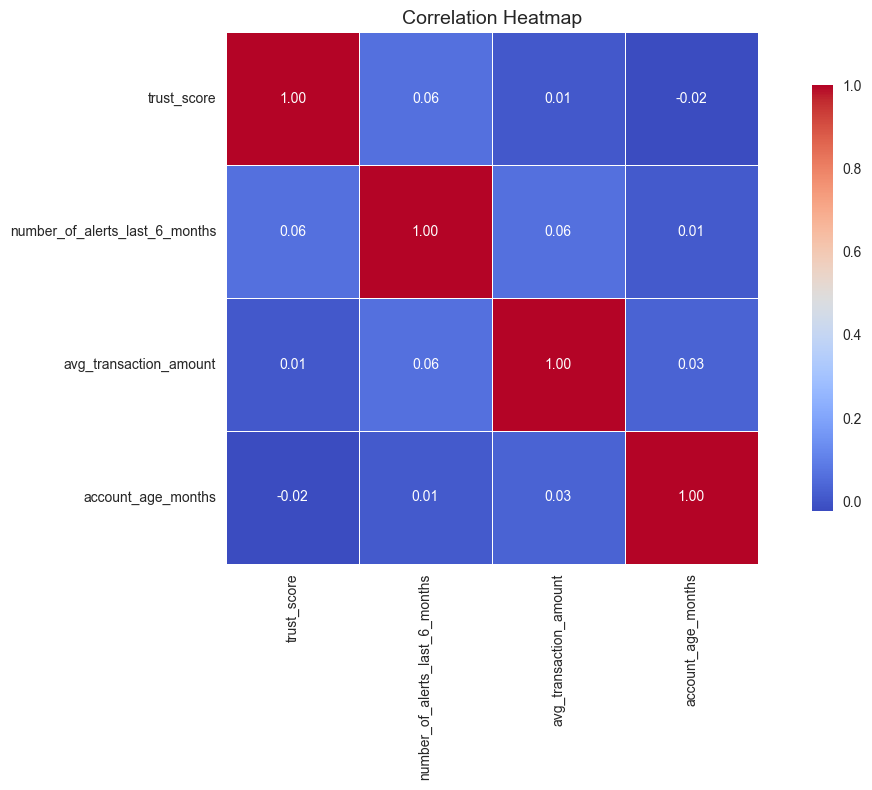

In [30]:
fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,           # poprawka: powinno być 'annot' zamiast 'annotation'
    fmt='.2f',
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": 0.8},
    cmap="coolwarm",
)

ax.set_title("Correlation Heatmap", fontsize=14)
plt.tight_layout()       # poprawka: tight_layout, nie tight_lauout
plt.show()

### Summary numerical value:


### Categorical values

In [31]:
import math

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def dist_categorical_visualisation(
        df: pd.DataFrame,
        categorical_cols: list[str],
        n_cols: int = 2,
        figsize: tuple | None = None,
        title: str | None = "Categorical Feature Distributions",
        save_path: str | None = None
) -> tuple[plt.Figure, dict[str, plt.Axes]] | None:
    """
    Plots count distributions for multiple categorical columns using subplots, in a clean and professional style.

    Args:
        df: DataFrame containing the data.
        categorical_cols: List of column names to visualize.
        n_cols: Number of columns in the subplot grid.
        figsize: Size of the entire figure. If None, inferred automatically.
        title: Title of the whole figure.
        save_path: If provided, saves the figure to this path instead of displaying it.
    """

    n = len(categorical_cols)
    n_rows = math.ceil(n / n_cols)
    figsize = figsize or (6 * n_cols, 4.5 * n_rows)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, ax=ax, color="steelblue", edgecolor="black")
        ax.set_title(f"Distribution of {col}", fontsize=13, weight="bold")
        ax.set_xlabel("Count", fontsize=11)
        ax.set_ylabel(col, fontsize=11)
        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=9)
        max_val = df[col].value_counts().max()
        ax.set_xlim(0, max_val * 1.1)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    if title:
        fig.suptitle(title, fontsize=16, weight="bold")
        fig.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        fig.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

    return fig, axes

In [36]:
df['category'] = df['category'].astype('category')

df['country'] = df['country'].astype('category')
df["has_fraud_history"] =df["has_fraud_history"].astype('category')

In [37]:
categorical_cals = ["category","country","has_fraud_history"]

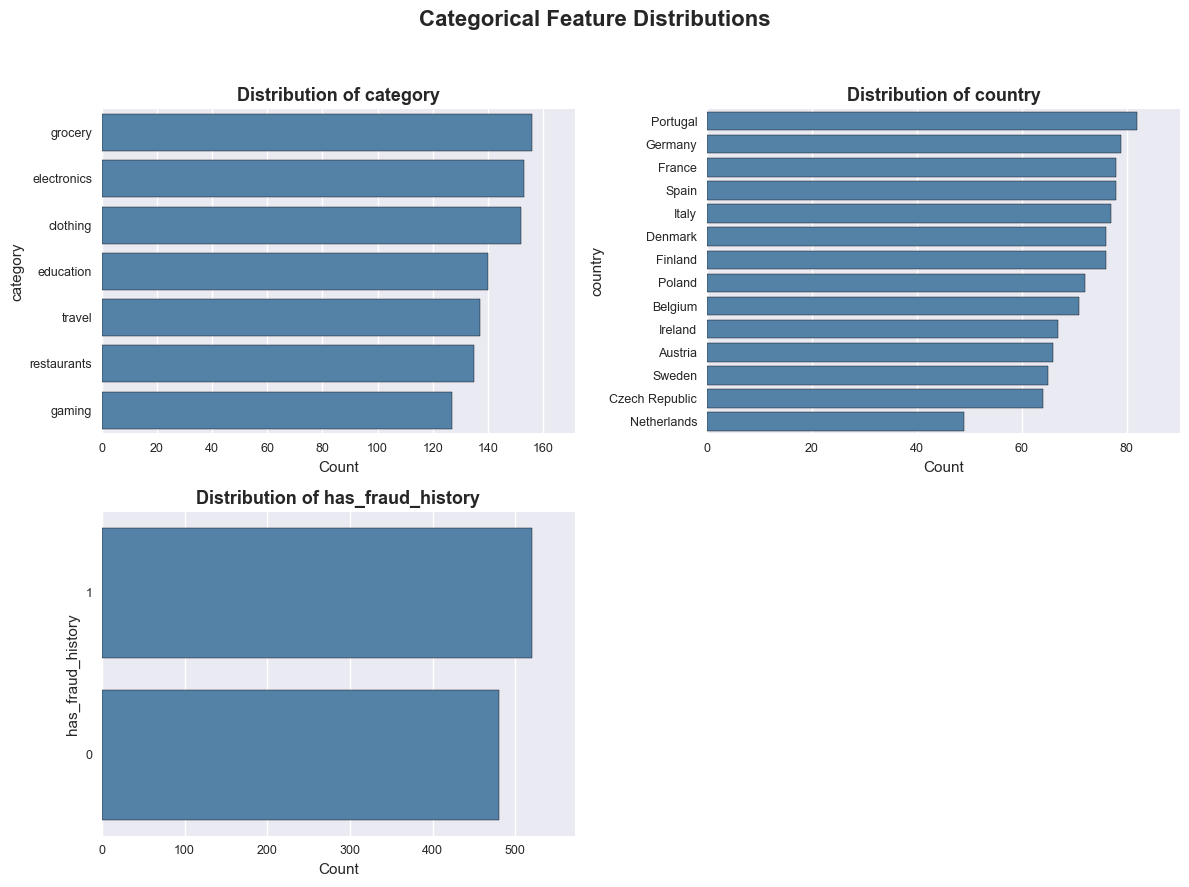

(<Figure size 1200x900 with 4 Axes>,
 array([<Axes: title={'center': 'Distribution of category'}, xlabel='Count', ylabel='category'>,
        <Axes: title={'center': 'Distribution of country'}, xlabel='Count', ylabel='country'>,
        <Axes: title={'center': 'Distribution of has_fraud_history'}, xlabel='Count', ylabel='has_fraud_history'>,
        <Axes: >], dtype=object))

In [38]:
dist_categorical_visualisation(df, categorical_cals)